Here is a simpler example of the use of LIME for image classification by using Keras (v2 or greater)

In [1]:
import os
import keras
from keras.applications import xception as inc_net
from keras.preprocessing import image
from keras.models import load_model
from keras.applications.imagenet_utils import decode_predictions
from skimage.io import imread
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
print('Notebook run using keras:', keras.__version__)

Using TensorFlow backend.


Notebook run using keras: 2.2.4


# Using Inception
Here we create a standard InceptionV3 pretrained model and use it on images by first preprocessing them with the preprocessing tools

In [2]:
import h5py

f = h5py.File('E:/expr1/Xception-with-Your-Own-Dataset/result_exp1/model_fine_final.h5','r+')

data_p = f.attrs['training_config']
data_p = data_p.decode().replace("learning_rate","lr").encode()
f.attrs['training_config'] = data_p
f.close()

inet_model = load_model('E:/expr1/Xception-with-Your-Own-Dataset/result_exp1/model_fine_final.h5')


Instructions for updating:
Colocations handled automatically by placer.
Instructions for updating:
Use tf.cast instead.


In [3]:
def transform_img_fn(path_list):
    out = []
    for img_path in path_list:
        img = image.load_img(img_path, target_size=(299, 299))
        x = image.img_to_array(img)
        x = np.expand_dims(x, axis=0)
        x = inc_net.preprocess_input(x)
        out.append(x)
    return np.vstack(out)

In [4]:
import lime

## Let's see the top 5 prediction for some image

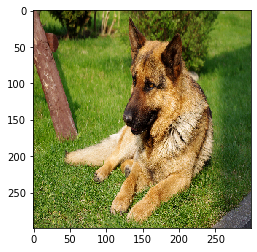

(1, 299, 299, 3)
german_shepherd, 100.00%
BACKGROUND_Google, 0.00%


In [5]:
import csv
import os
#img_path = 'c:/Users/andradee/\Documents/audiodeep/image_downloader/image_downloader/images/german-shepherd 2020_09_11_total/teste/11.german-shepherd-dog.png'
img_path = 'c:/Users/andradee/\Documents/audiodeep/image_downloader/image_downloader/images/german-shepherd 2020_09_11_total/teste/8.German-Shepherd-Dog-Pictures-2.png'

img = image.load_img(img_path, target_size=(299, 299))

img_tensor = image.img_to_array(img)
img_tensor = np.expand_dims(img_tensor, axis=0)
img_tensor /= 255.

plt.imshow(img_tensor[0])
plt.show()

print(img_tensor.shape)

file_class='E:/expr1/Xception-with-Your-Own-Dataset/classes_exp1_german_add.txt'

classes = []
with open(file_class, 'r') as f:
    classes = list(map(lambda x: x.strip(), f.readlines()))



x = image.img_to_array(img)
x = np.expand_dims(x, axis=0)

x = inc_net.preprocess_input(x)


images = np.vstack([x])
pred = inet_model.predict(images, batch_size=10)

num_class=pred.shape[1]

result = [(classes[i], float(pred[0,i]) * 100.0) for i in range(num_class)]
result.sort(reverse=True, key=lambda x: x[1])

for i in range(num_class):
    (class_name, prob) = result[i]
    #print(i)
    #print("Top %d ====================" % (i + 1))
    #print("Class name: %s" % (class_name))
    #print("Probability: %.2f%%" % (prob))
    print('%s, %.2f%%' % (class_name, prob))

#print("Predicted class is",pred)

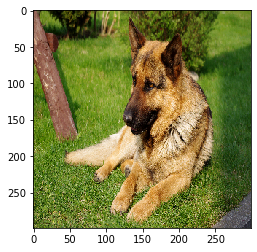

In [6]:
#images = transform_img_fn([os.path.join('','doberman1.jpg')])
# I'm dividing by 2 and adding 0.5 because of how this Inception represents images
plt.imshow(images[0] / 2 + 0.5)
#plt.imshow(images[0] / 255)
#preds = inet_model.predict(images)
preds=pred
#for x in decode_predictions(preds)[0]:
#    print(x)

## Explanation
Now let's get an explanation

In [7]:
%load_ext autoreload
%autoreload 2
import os,sys
try:
    import lime
except:
    sys.path.append(os.path.join('..', '..')) # add the current directory
    import lime
from lime import lime_image

In [8]:
explainer = lime_image.LimeImageExplainer()

hide_color is the color for a superpixel turned OFF. Alternatively, if it is NONE, the superpixel will be replaced by the average of its pixels. Here, we set it to 0 (in the representation used by inception model, 0 means gray)

In [72]:
%%time
# Hide color is the color for a superpixel turned OFF. Alternatively, if it is NONE, the superpixel will be replaced by the average of its pixels
explanation = explainer.explain_instance(images[0], inet_model.predict, top_labels=5,hide_color=0, num_samples=1000)

Wall time: 38.2 s


Image classifiers are a bit slow. Notice that an explanation on my Surface Book dGPU took 1min 29s

### Now let's see the explanation for the top class ( Black Bear)

We can see the top 5 superpixels that are most positive towards the class with the rest of the image hidden

In [73]:
from skimage.segmentation import mark_boundaries
print(explanation.top_labels[0])

1


(299, 299, 3)


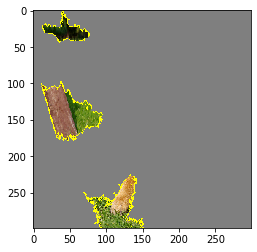

In [74]:
temp, mask = explanation.get_image_and_mask(explanation.top_labels[1], positive_only=True, num_features=5, hide_rest=True)
plt.imshow(mark_boundaries(temp / 2 + 0.5, mask))
print(temp.shape)



Or with the rest of the image present:

In [75]:
mask

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=int64)

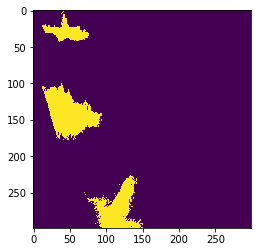

In [76]:
plt.imshow(mask, interpolation='nearest')
plt.show()

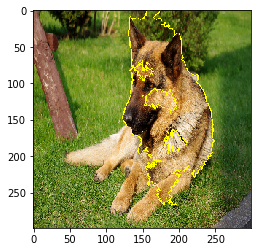

In [77]:
temp, mask = explanation.get_image_and_mask(explanation.top_labels[0], positive_only=True, num_features=8, hide_rest=False)
plt.imshow(mark_boundaries(temp / 2 + 0.5, mask))
#plt.imshow(mark_boundaries(temp / 2, mask))

In [78]:
mask.shape

import xlsxwriter

workbook = xlsxwriter.Workbook('arrays2.xlsx')
worksheet = workbook.add_worksheet()

#array = [['a1', 'a2', 'a3'],
#         ['a4', 'a5', 'a6'],
#         ['a7', 'a8', 'a9'],
#         ['a10', 'a11', 'a12', 'a13', 'a14']]

array = mask

np.transpose(array)

row = 0

for col, data in enumerate(array):
    worksheet.write_column(row, col, data)

workbook.close()


In [79]:
mask.shape


(299, 299)

We can also see the 'pros and cons' (pros in green, cons in red)

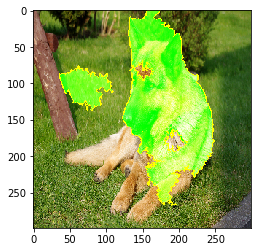

In [80]:
temp, mask = explanation.get_image_and_mask(explanation.top_labels[0], positive_only=False, num_features=10, hide_rest=False)
plt.imshow(mark_boundaries(temp / 2 + 0.5, mask))

Or the pros and cons that have weight at least 0.1

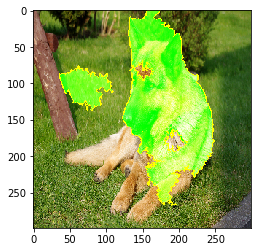

In [81]:
temp, mask = explanation.get_image_and_mask(explanation.top_labels[0], positive_only=False, num_features=10, hide_rest=False, min_weight=0.001)
plt.imshow(mark_boundaries(temp / 2 + 0.5, mask))


### Let's see the explanation for the second highest prediction

Most positive towards wombat:

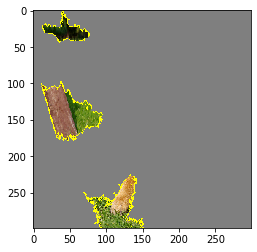

In [82]:
temp, mask = explanation.get_image_and_mask(explanation.top_labels[1], positive_only=True, num_features=5, hide_rest=True)
plt.imshow(mark_boundaries(temp / 2 + 0.5, mask))

Pros and cons:

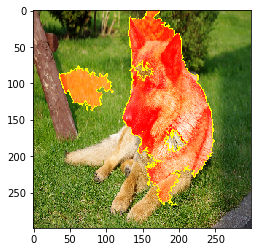

In [83]:
temp, mask = explanation.get_image_and_mask(explanation.top_labels[1], positive_only=False, num_features=10, hide_rest=False)
plt.imshow(mark_boundaries(temp / 2 + 0.5, mask))


In [84]:
mask.shape

(299, 299)

In [85]:
mask2_path = 'c:/Users/andradee/\Documents/audiodeep/image_downloader/image_downloader/images/german-shepherd 2020_09_11_total/mask/8.German-Shepherd-Dog-Pictures-2.png'
mask2 = image.load_img(mask2_path, target_size=(299, 299))

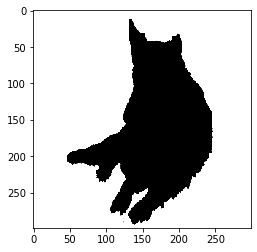

In [87]:
mask2_tensor = image.img_to_array(mask2)
mask2_tensor = np.expand_dims(mask2_tensor, axis=0)
mask2_tensor /= 255.

plt.imshow(mask2_tensor[0])
plt.show()

In [88]:
def converter(x):

    #x has shape (batch, width, height, channels)
    return (0.21 * x[:,:,:,:1]) + (0.72 * x[:,:,:,1:2]) + (0.07 * x[:,:,:,-1:])

In [89]:
mask2=converter(mask2_tensor)

In [90]:
mask2.shape


(1, 299, 299, 1)

In [91]:
mask2 = mask2.reshape([ 299, 299])

In [92]:
mask2=(mask2 < 1)


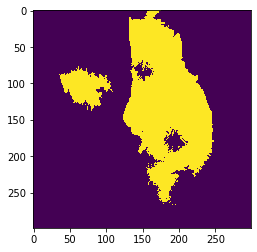

In [94]:
#mask3=(mask>-1) #verificar valores diferentes de 1 e 0 
mask=1-mask

plt.imshow(mask)
plt.show()

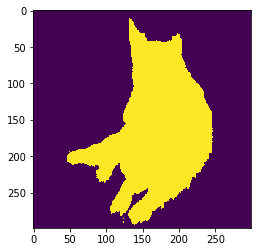

In [95]:
plt.imshow(mask2)
plt.show()

In [96]:
maskf_fp=(1-mask2)*mask #falso positivo
maskf_fn=mask2*(1-mask) #falso negativo
maskf_tp=mask2*mask #verdadeiro positivo
maskf_tn=(1-mask2)*(1-mask) #verdadeiro negativo

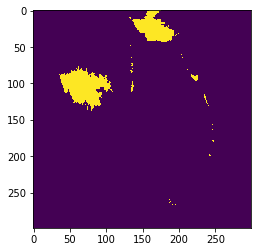

In [97]:
plt.imshow(maskf_fp)
plt.show()

In [100]:
fp= np.count_nonzero(maskf_fp == 1)/ (299*299) *100
fn = np.count_nonzero(maskf_fn == 1)/ (299*299) *100
tp =np.count_nonzero(maskf_tp == 1)/ (299*299) *100
tn = np.count_nonzero(maskf_tn == 1)/ (299*299) *100
print("FP:",tp)
print("FN:", fn)
print("TP:",tp)
print("TN:",tn)
print("Acurracy:", (tp+tn))
print("Precision:", (tp/(tp+fp))*100)
print("Recall:", (tp/(tp+fn))*100)
print("Specificity:", (tn/(tn+fp)*100))

FP: 18.871153566514916
FN: 10.47191865862798
TP: 18.871153566514916
TN: 66.32811713515508
Acurracy: 85.19927070167
Precision: 81.34130466226314
Recall: 64.31212594823313
Specificity: 93.8734802431611


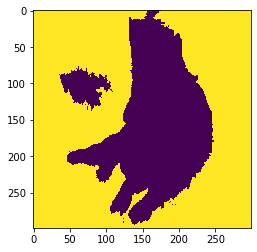

In [101]:
plt.imshow(maskf_tn)
plt.show()

In [35]:
import xlsxwriter

workbook = xlsxwriter.Workbook('arrays6.xlsx')
worksheet = workbook.add_worksheet()

#array = [['a1', 'a2', 'a3'],
#         ['a4', 'a5', 'a6'],
#         ['a7', 'a8', 'a9'],
#         ['a10', 'a11', 'a12', 'a13', 'a14']]

array = mask

np.transpose(array)

row = 0

for col, data in enumerate(array):
    worksheet.write_column(row, col, data)

workbook.close()


In [175]:
print(np.count_nonzero(maskf == 1))

19828


TypeError: unhashable type: 'numpy.ndarray'

In [176]:
print(np.count_nonzero(mask == 1))

24586


In [177]:
print(np.count_nonzero(mask2 == 1))

33275


In [178]:
f=np.count_nonzero(maskf == 1)
m=np.count_nonzero(mask2 == 1)
p=f/m
print(p)

0.5958827948910593
